# Sidewalk Segmentation Dataset — Visualisation

COCO-format dataset with **5 classes** and polygon segmentation masks.

| id | class | description |
|---|---|---|
| 0 | Sidewalks | general sidewalk area |
| 1 | Roadway | road / carriageway |
| 2 | downstairs | descending stairs |
| 3 | sidewalk | specific sidewalk segment |
| 4 | upstairs | ascending stairs |

Splits: **train** (1547 imgs) · **valid** (244 imgs) · **test** (139 imgs)

## 1. Imports & paths

In [1]:
import json, random
from pathlib import Path
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATASET_ROOT = Path('../../../../datasets/sidewalk_segmentation')
SPLIT        = 'train'   # change to 'valid' or 'test'

ann_path = DATASET_ROOT / SPLIT / '_annotations.coco.json'
with open(ann_path) as f:
    coco = json.load(f)

# Build fast lookup dicts
id2img  = {img['id']: img  for img in coco['images']}
id2cat  = {cat['id']: cat  for cat in coco['categories']}

# Group annotations by image id
from collections import defaultdict
img2anns = defaultdict(list)
for ann in coco['annotations']:
    img2anns[ann['image_id']].append(ann)

print(f"Split   : {SPLIT}")
print(f"Images  : {len(coco['images'])}")
print(f"Anns    : {len(coco['annotations'])}")
print(f"Classes : {[c['name'] for c in coco['categories']]}")

Split   : train
Images  : 1547
Anns    : 2381
Classes : ['Sidewalks', 'Roadway', 'downstairs', 'sidewalk', 'upstairs']


## 2. Colour palette per class

In [2]:
# Distinct, accessible colours for 5 classes
PALETTE = {
    0: (255, 180,   0, 160),   # Sidewalks  — amber
    1: (100, 149, 237, 160),   # Roadway    — cornflower blue
    2: (220,  20,  60, 160),   # downstairs — crimson
    3: ( 50, 205,  50, 160),   # sidewalk   — lime green
    4: (238, 130, 238, 160),   # upstairs   — violet
}

handles = [
    mpatches.Patch(
        facecolor=tuple(c/255 for c in PALETTE[cat['id']][:3]),
        alpha=PALETTE[cat['id']][3]/255,
        edgecolor='#333', linewidth=0.5,
        label=f"{cat['id']}  {cat['name']}"
    )
    for cat in coco['categories']
]
print("Palette ready — classes:", [c['name'] for c in coco['categories']])

Palette ready — classes: ['Sidewalks', 'Roadway', 'downstairs', 'sidewalk', 'upstairs']


## 3. Helper — draw masks on image

In [3]:
def draw_masks(img_id: int, alpha: float = 0.45) -> np.ndarray:
    meta  = id2img[img_id]
    img_p = DATASET_ROOT / SPLIT / meta['file_name']
    img   = Image.open(img_p).convert('RGBA')
    w, h  = img.size

    overlay = Image.new('RGBA', (w, h), (0, 0, 0, 0))
    draw    = ImageDraw.Draw(overlay)

    for ann in img2anns[img_id]:
        colour = PALETTE.get(ann['category_id'], (200, 200, 200, 140))
        for seg in ann['segmentation']:
            if len(seg) < 6:   # need at least 3 points
                continue
            pts = [(seg[i], seg[i+1]) for i in range(0, len(seg), 2)]
            draw.polygon(pts, fill=colour, outline=(255, 255, 255, 200))

    blended = Image.alpha_composite(img, overlay).convert('RGB')
    return np.array(blended)

## 4. Grid — random sample from split

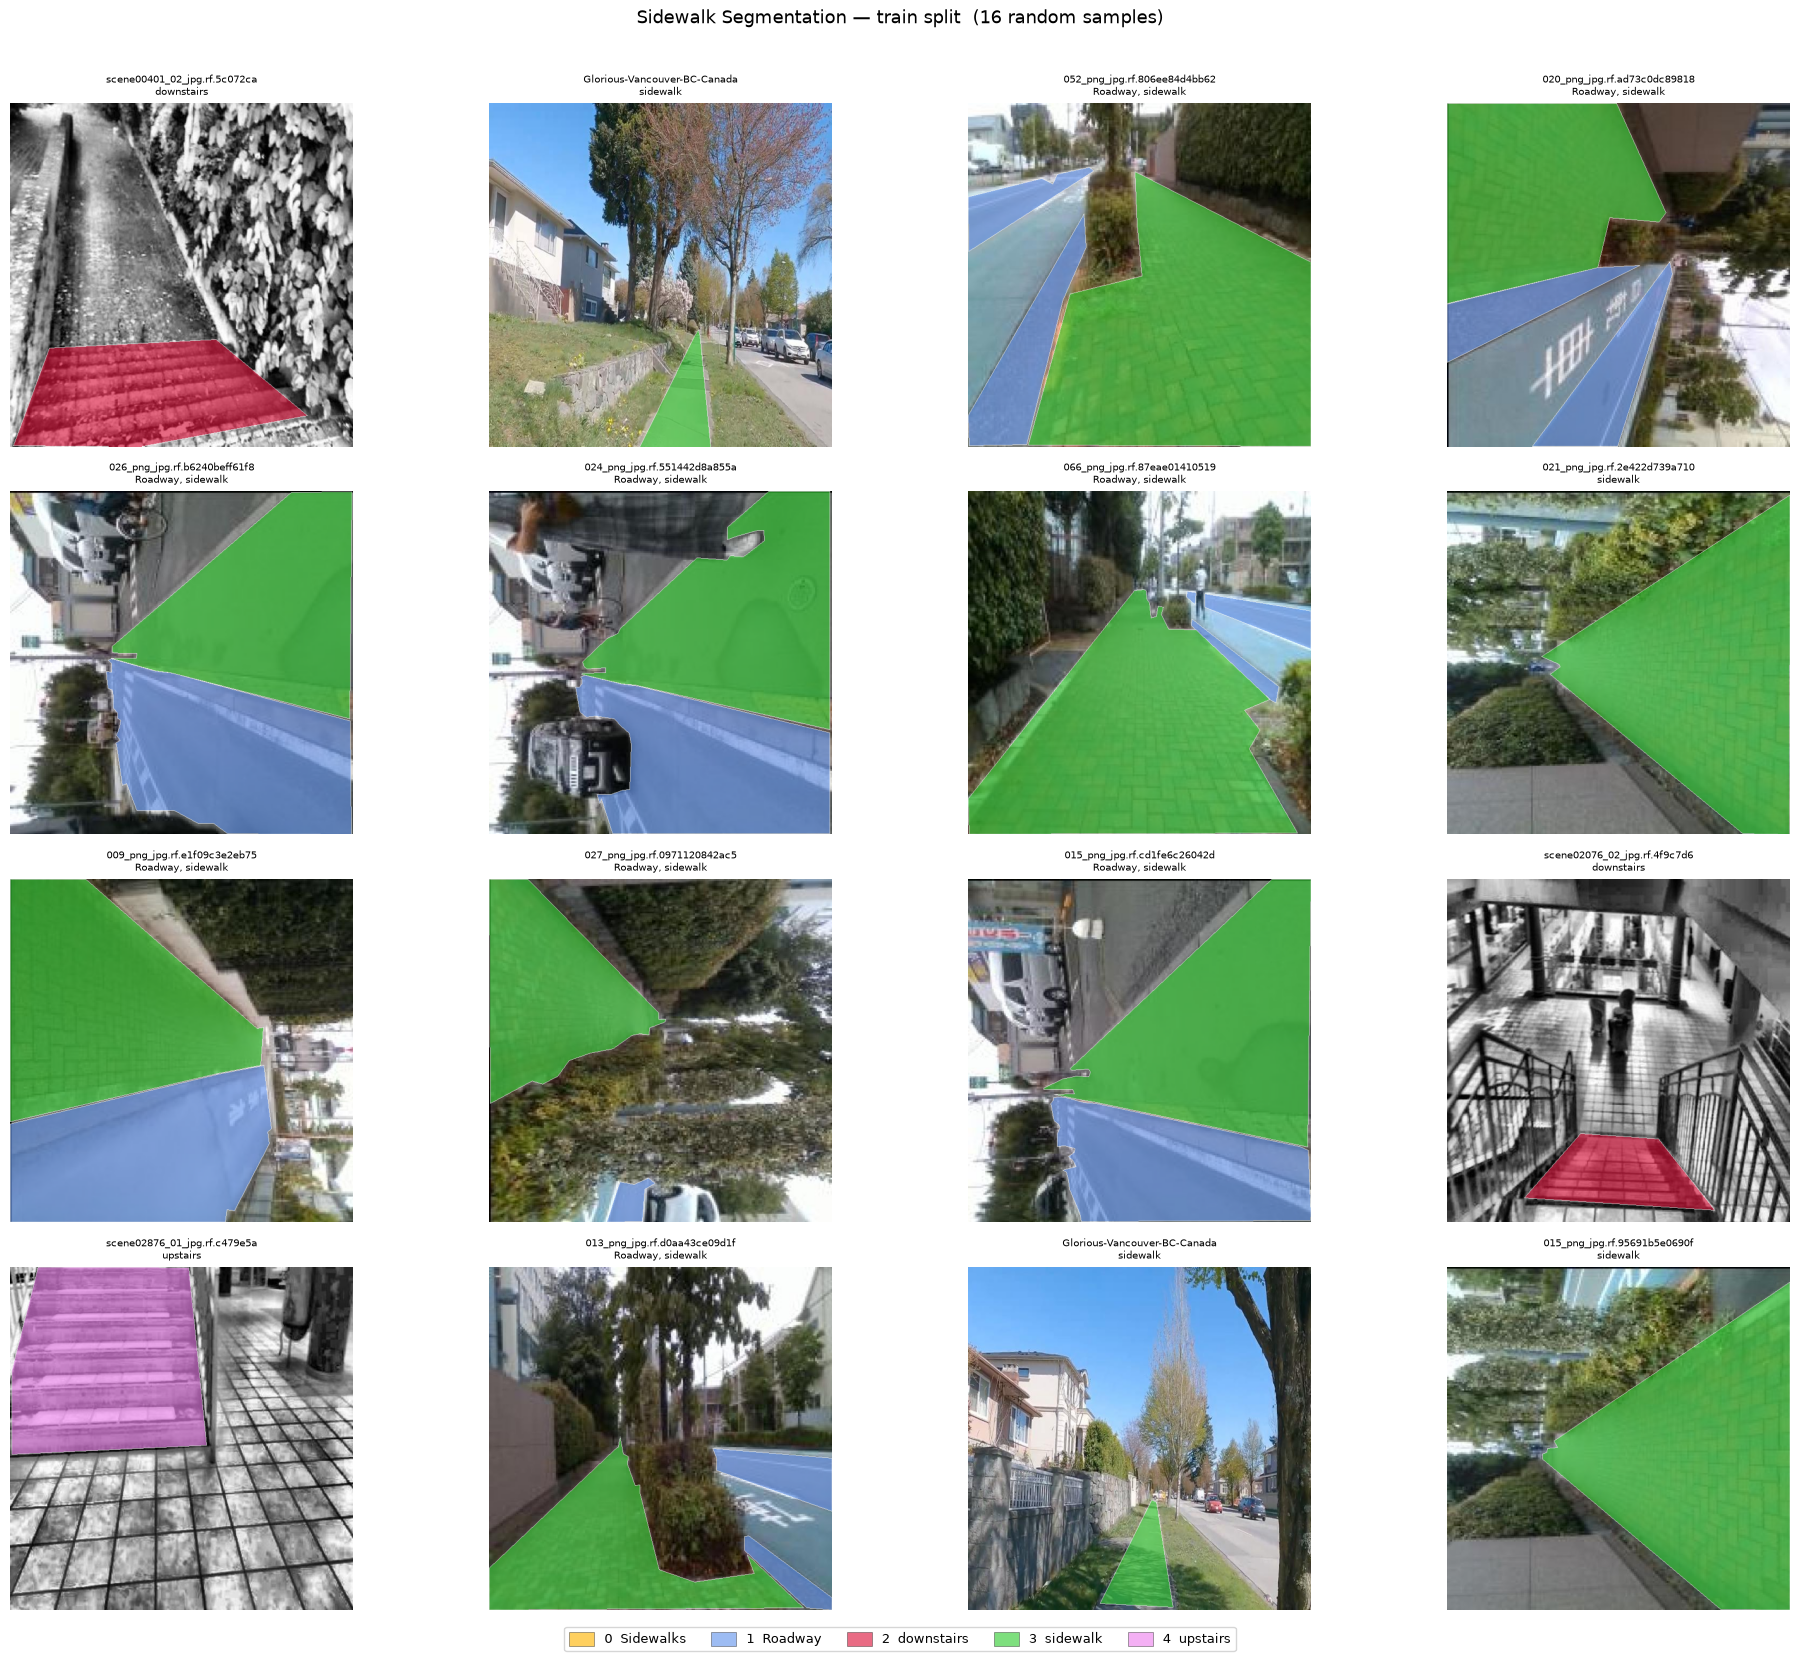

In [4]:
N_COLS = 4
N_ROWS = 4
N      = N_COLS * N_ROWS

# Only pick images that have at least one annotation
annotated_ids = [img_id for img_id in id2img if img2anns[img_id]]
sample_ids    = random.sample(annotated_ids, min(N, len(annotated_ids)))

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(5 * N_COLS, 4 * N_ROWS))
axes = axes.flatten()

for ax, img_id in zip(axes, sample_ids):
    rendered = draw_masks(img_id)
    meta     = id2img[img_id]
    cats     = {id2cat[a['category_id']]['name'] for a in img2anns[img_id]}
    ax.imshow(rendered)
    ax.set_title(f"{meta['file_name'][:28]}\n{', '.join(sorted(cats))}", fontsize=7)
    ax.axis('off')

for ax in axes[len(sample_ids):]:
    ax.axis('off')

fig.legend(handles=handles, loc='lower center', ncol=5,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02),
           handlelength=2, handleheight=1.4)
plt.suptitle(f'Sidewalk Segmentation — {SPLIT} split  ({N} random samples)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Single image — full detail

Image : scene00451_02_jpg.rf.e2b39ff789618c40bc6fdbcf24498618.jpg
Size  : 640 x 640
Annotations: 5
  [4] upstairs  area=2132  bbox=[517, 104, 26, 82]
  [4] upstairs  area=3636  bbox=[471, 99, 44, 83]
  [4] upstairs  area=3720  bbox=[419, 97, 47, 79]
  [4] upstairs  area=8455  bbox=[416, 186, 51, 167]
  [4] upstairs  area=35330  bbox=[234, 158, 183, 193]


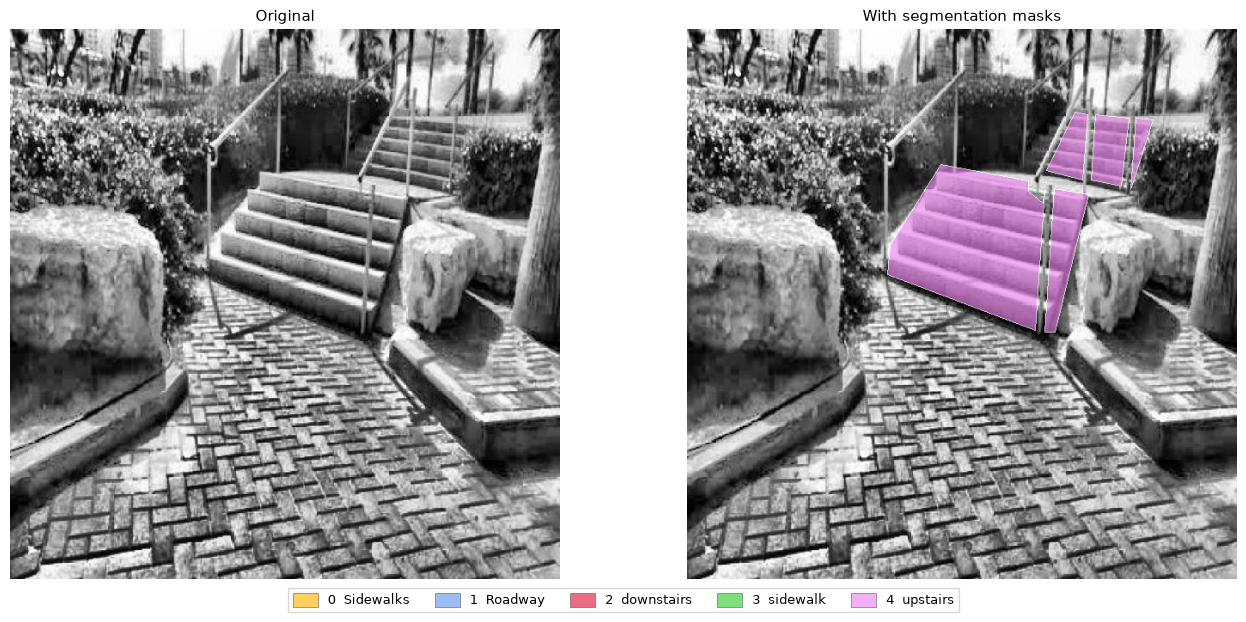

In [5]:
# Pick the image with most annotations for a detailed view
richest_id = max(annotated_ids, key=lambda i: len(img2anns[i]))
meta       = id2img[richest_id]
print(f"Image : {meta['file_name']}")
print(f"Size  : {meta['width']} x {meta['height']}")
print(f"Annotations: {len(img2anns[richest_id])}")
for ann in img2anns[richest_id]:
    cat = id2cat[ann['category_id']]
    print(f"  [{cat['id']}] {cat['name']}  area={ann['area']:.0f}  bbox={[round(v) for v in ann['bbox']]}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

orig = np.array(Image.open(DATASET_ROOT / SPLIT / meta['file_name']).convert('RGB'))
ax1.imshow(orig); ax1.set_title('Original', fontsize=11); ax1.axis('off')

masked = draw_masks(richest_id)
ax2.imshow(masked); ax2.set_title('With segmentation masks', fontsize=11); ax2.axis('off')

fig.legend(handles=handles, loc='lower center', ncol=5,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.04),
           handlelength=2, handleheight=1.4)
plt.tight_layout()
plt.show()

## 6. Class distribution

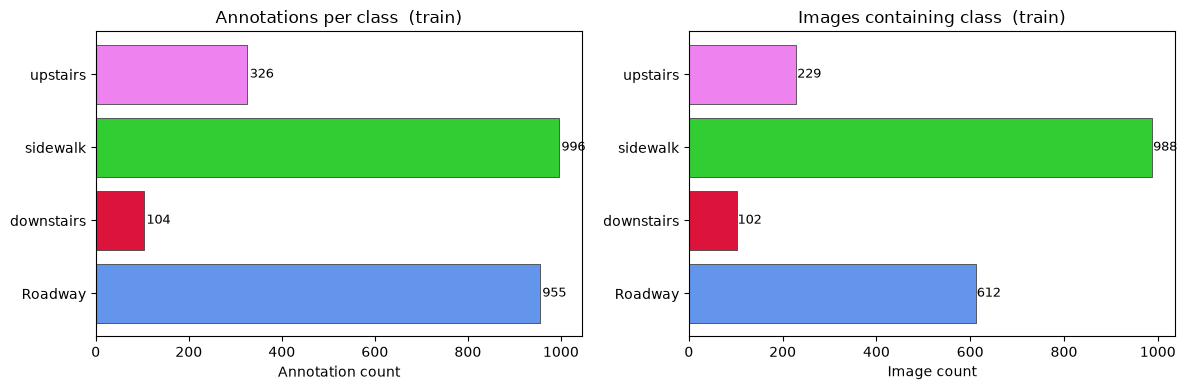

: 

In [ ]:
from collections import Counter

cat_counts = Counter(ann['category_id'] for ann in coco['annotations'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Annotation count per class
names  = [id2cat[i]['name'] for i in sorted(cat_counts)]
counts = [cat_counts[i] for i in sorted(cat_counts)]
colors = [tuple(c/255 for c in PALETTE[i][:3]) for i in sorted(cat_counts)]
ax1.barh(names, counts, color=colors, edgecolor='#444', linewidth=0.6)
ax1.set_xlabel('Annotation count')
ax1.set_title(f'Annotations per class  ({SPLIT})')
for i, v in enumerate(counts):
    ax1.text(v + 5, i, str(v), va='center', fontsize=9)

# Images that contain each class
img_per_class = {cat_id: len({a['image_id'] for a in coco['annotations'] if a['category_id'] == cat_id})
                 for cat_id in sorted(cat_counts)}
img_names  = [id2cat[i]['name'] for i in img_per_class]
img_counts = list(img_per_class.values())
ax2.barh(img_names, img_counts, color=colors, edgecolor='#444', linewidth=0.6)
ax2.set_xlabel('Image count')
ax2.set_title(f'Images containing class  ({SPLIT})')
for i, v in enumerate(img_counts):
    ax2.text(v + 2, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()